### Deficiniones útiles para iniciar a trabajar con datos

### Clasificación del conjunto de datos (dataset)

1. **Cross-sectional [corte transversal]:** tengo variables sobre un conjunto de registros en un corte específico del tiempo. **IDD: Independientes e identicamente distribuidos**
2. **Time series [series temporales]:** son registros indexados por el tiempo.
3. Longitudinales: 

**Variable:** Una característica observable. Cuando la carcateristica no se observa hablamos de *variables latentes* y generalmente se tratantan con *proxys*. 

- **Cuantitativas:** escala numérica de medición
    - Continuas: medición [Dominio reales] float()
    - Discretas: Conteo [Dominio enteros] int()
- **Cualitativas:** escala categóriga de medición. 
    - Ordinales: orden implícito
    - Nominales: sin orden implícito


### Análsis exploratorio de los datos [EDA]

1. Métodos tabulares
2. Métodos numéricos
3. Métodos gráficos


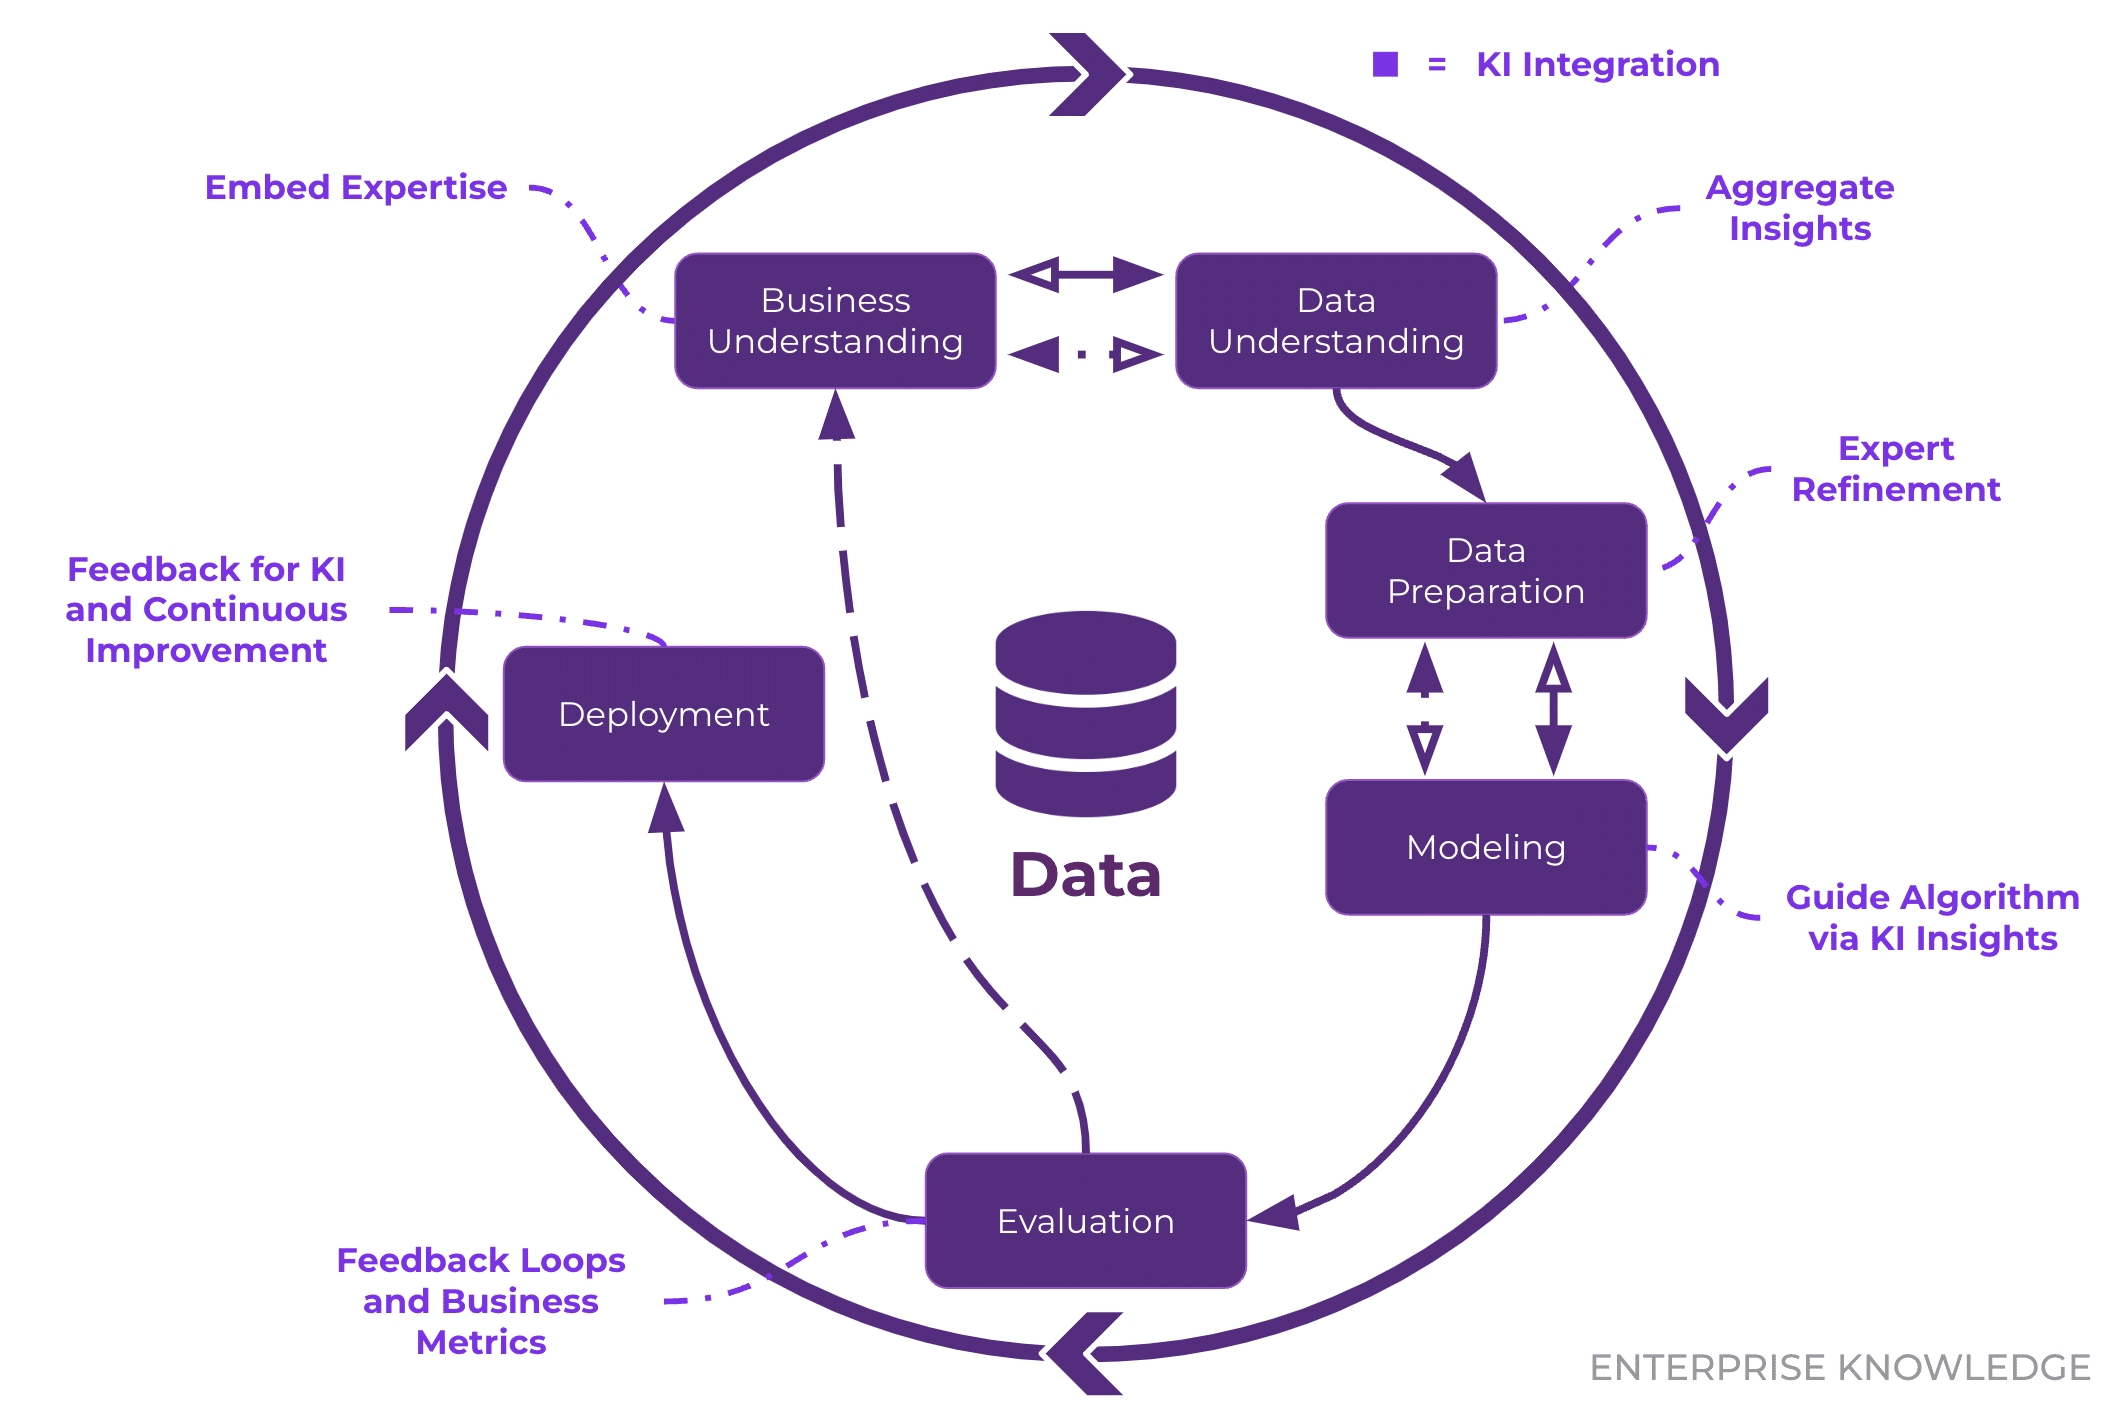



In [1]:
# Vamos a importar nuestras herramientas de trabajo

# Son modulos para manejar de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# df = pd.read_csv("C:\\Users\\Julian\\Desktop\\datos ejemplos\\family_anxiety_14_dataset.csv")
# df.sample(3)

In [3]:
penguins = sns.load_dataset('penguins')
stock= sns.load_dataset('dowjones')

In [4]:
type(penguins)

pandas.core.frame.DataFrame

In [5]:
penguins.sample(5) # los registros son independientes identicamente distribuidos [IID]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
190,Chinstrap,Dream,46.9,16.6,192.0,2700.0,Female
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,Female
141,Adelie,Dream,40.6,17.2,187.0,3475.0,Male
180,Chinstrap,Dream,46.4,17.8,191.0,3700.0,Female


In [6]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
# Valores perdidos (missing values)

penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
penguins.shape, penguins.columns

((344, 7),
 Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
        'flipper_length_mm', 'body_mass_g', 'sex'],
       dtype='object'))

In [9]:
n = len(penguins)
print(f'Se registran {n} pinguinos')

Se registran 344 pinguinos


In [10]:
# Cómo accede a una variable específica

print(penguins.columns)

penguins.species

penguins[['species','island']].sample(4)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


,species,island
338,Gentoo,Biscoe
339,Gentoo,Biscoe
23,Adelie,Biscoe
287,Gentoo,Biscoe


#### Análisis exploratorio de los datos

1. Métodos tabulares
2. Métodos numéricos
3. Métodos gráficos

In [11]:
# Tablas de frecuencias

# Cuántas especies hay

print(penguins.species.unique())

# Cuántos registros por especie hay
print('Veamos la tabla de frecuencia absoluta de las especies \n')
print(f'{penguins.species.value_counts()} \n') # Frecuencia absoluta (contar en una unidad lineal)
print('Ahora observemos la tabla de frecuencia relativa del sexo \n')
penguins.sex.value_counts(dropna= False, normalize= True) * 100 # Frecuencia [normalizada] relativa

['Adelie' 'Chinstrap' 'Gentoo']
Veamos la tabla de frecuencia absoluta de las especies 

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64 

Ahora observemos la tabla de frecuencia relativa del sexo 



sex
Male      48.837209
Female    47.965116
NaN        3.197674
Name: proportion, dtype: float64

In [12]:
# Probemos que la frecuencia relativa se calcula como n_{k} / n, siendo k la clase se interés
152 / n, penguins.species.value_counts(normalize= True)

(0.4418604651162791,
 species
 Adelie       0.441860
 Gentoo       0.360465
 Chinstrap    0.197674
 Name: proportion, dtype: float64)

In [13]:
# Tablas cruzadas, tablas de contingencia

pd.crosstab(penguins.species, penguins.island, dropna= False)

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


Text(0.5, 0, 'Especie')

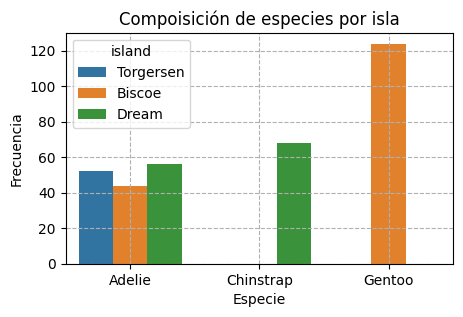

In [14]:
plt.figure(figsize= (5,3))
plt.title('Compoisición de especies por isla')
sns.countplot(data = penguins, x = 'species', hue = 'island')
plt.grid(linestyle = '--')
plt.ylabel('Frecuencia')
plt.xlabel('Especie')

In [15]:
np.mean(penguins[penguins.sex == 'Male']['bill_length_mm'])
np.mean(penguins[penguins.sex == 'Female']['bill_length_mm'])

np.float64(42.096969696969694)

In [16]:
penguins[penguins.island == 'Torgersen']
penguins[penguins.bill_length_mm >= 39.5]

penguins[(penguins.island == 'Torgersen') | 
         (penguins.bill_length_mm > 39.5) &
         (penguins.species != 'Adelie')]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [17]:
# ¿Podríamos usar tablas con medidas distintas a la frecuencia?
# Por ejemplos mirar si hay especies en función de el promedio de la longitud del pico

penguins.groupby(['species'])['bill_length_mm'].mean()

species
Adelie       38.791391
Chinstrap    48.833824
Gentoo       47.504878
Name: bill_length_mm, dtype: float64

In [18]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [19]:
# Hay diferencia en masa corporal según especie
# Hay diferencia en masa corporal según isla
# En Adelie cambia la masa corporal según la isla de la que vengan 

In [20]:
penguins.groupby(['species'])['body_mass_g'].mean()

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

In [21]:
penguins.groupby(['island'])['body_mass_g'].mean()

island
Biscoe       4716.017964
Dream        3712.903226
Torgersen    3706.372549
Name: body_mass_g, dtype: float64

In [22]:
# En Adelie cambia la masa corporal según la isla de la que vengan 



pinguinos_adelei = penguins[penguins.species == 'Adelie']

pinguinos_adelei.groupby(['island'])['body_mass_g'].mean()

island
Biscoe       3709.659091
Dream        3688.392857
Torgersen    3706.372549
Name: body_mass_g, dtype: float64

In [23]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [24]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

# Tarea

1. Cuántos pinguinos son Adelei y tiene un bill_length_mm superior a 45mm
2.  Haga una tabla del promedio de masa corporal de los pinguinos, cual es mas pesado
3. Cuantos punguinos son Hembras y pesan mas que 4201 g
4. Qué es especie tiene el promedio de masa corporal en machos mayor
5. Hay alguna diferencia significativa entre las aletas en Adelei segun la isla en la que se encuentren?

#### Métodos numéricos

1. Medidas de centralidad: media, moda, mediana
2. Medidas de dispersion:
3. Medidas de posición:
4. Medidas de forma:

In [25]:
# Demostración de que la media es el punto de gravedad

media = penguins.bill_length_mm.mean()

diferencia = penguins.bill_length_mm - media

diferencia.sum()

np.float64(2.2737367544323206e-13)

In [26]:
ej = np.array([20,22,20,60,20,59,21]) # outliers [datos atípicos]
ej.mean() # Es muy sensible a outliers; es una medida poco robusta. 
np.median(ej) # Está es poco sensible a atípicos; es una medida robusta. 

np.float64(21.0)

In [27]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [28]:
np.mean(penguins.bill_length_mm)

np.float64(43.9219298245614)

In [29]:
penguins[penguins.bill_length_mm.isna() == False].bill_length_mm.median()

np.float64(44.45)

In [30]:
penguins.describe(percentiles= [.25,.50,.75])

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [31]:
x = np.random.randint(20,40, size = 100)
x

array([38, 35, 25, 21, 36, 29, 24, 34, 20, 21, 32, 20, 25, 39, 27, 23, 20,
       37, 35, 21, 31, 33, 33, 37, 34, 27, 29, 36, 37, 32, 30, 30, 32, 26,
       22, 33, 20, 32, 33, 34, 24, 37, 24, 27, 38, 25, 37, 21, 39, 34, 36,
       21, 23, 30, 30, 27, 34, 37, 38, 25, 38, 38, 27, 36, 20, 38, 37, 30,
       36, 36, 32, 39, 25, 33, 35, 36, 35, 37, 25, 36, 39, 25, 27, 32, 39,
       25, 30, 22, 29, 38, 21, 24, 26, 37, 24, 32, 23, 38, 35, 30],
      dtype=int32)

In [32]:
min(x), max(x), np.median(x), np.mean(x)

(np.int32(20), np.int32(39), np.float64(32.0), np.float64(30.55))

In [33]:
np.percentile(x, [25,50,75])

array([25., 32., 36.])

In [34]:
# No sé cuál es la función de IQR, entonces la creo

def IQR(x):
    if x.isna().sum() > 0:
        x = x[x.isna()== False]
        n25 = np.percentile(x, 25)
        n75 = np.percentile(x, 75)
    else: 
        n25 = np.percentile(x, 25)
        n75 = np.percentile(x, 75)
    return n75 - n25

In [35]:
IQR(penguins.bill_length_mm)

np.float64(9.274999999999999)

In [38]:
np.var(penguins.bill_length_mm), np.mean(penguins.bill_length_mm), np.std(penguins.bill_length_mm)

(np.float64(29.71989919975377),
 np.float64(43.9219298245614),
 np.float64(5.4515960231618195))

In [37]:
# Medida normalizada de la desviación
# Cuál es la medida normalizada
# Creen la función llamandola coef_var


In [68]:
# Normalización de la desviación

def coef_var(x):
    x = np.array(x)
    mu = np.mean(x)
    sd = np.std(x)
    return sd / mu

def puntuacion_z(x):
    x = np.array(x)
    mu = np.mean(x)
    sd = np.std(x)
    return (x - mu) / sd

In [45]:
min(x), max(x)
np.mean(x), np.std(x)

(np.float64(30.55), np.float64(6.020589672116843))

In [54]:
# Qué hacer con datos vacíos [missing values]
## 1. Eliminar los datos [na < 1%]
## 2. Imputar los datos: interpolación, suaviazación de medias moviles...

penguins.isna().sum()
2/len(penguins) *100

0.5813953488372093

In [56]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [ ]:
penguins.dropna(subset= ['bill_length_mm'], inplace= True)

In [63]:
penguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

In [65]:
np.mean(penguins.bill_length_mm), np.std(penguins.bill_length_mm)

(np.float64(43.9219298245614), np.float64(5.4515960231618195))

In [66]:
np.mean(penguins.bill_depth_mm), np.std(penguins.bill_depth_mm)

(np.float64(17.151169590643278), np.float64(1.9719039187562524))

In [ ]:
# Cuál de estos registros varia mas con respecto a su media

coef_var(penguins.bill_length_mm), coef_var(penguins.bill_depth_mm)

(np.float64(0.12412013873109133), np.float64(0.11497197951048267))

### Componente gráfico del AED

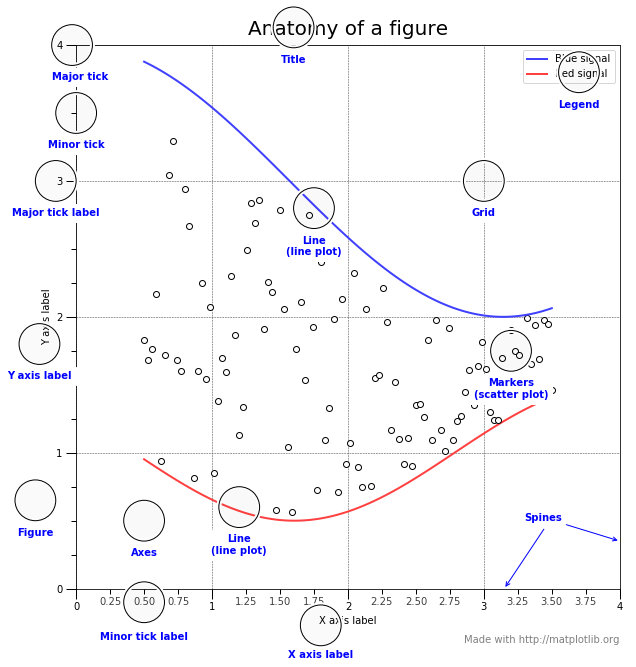

In [ ]:
# Tipo de datos
### Series de tiempo: grafico de lineas
### Cross-sectional: mayores posibiles ?

# Tipo de variables
### Variables cualitiativas: barras y sectores (torta o pie)
### Variables cuantitativas:
##### Discretas: barras y sectores (dependiendo del rango), boxplot y los histogramas
##### Continuas: boxplot y los histogramas

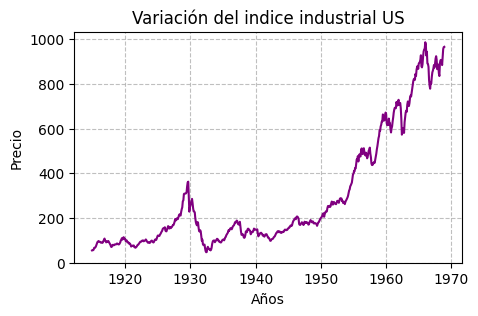

In [85]:
# Matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize= (5,3))
plt.plot(stock.Date, stock.Price, color = 'purple')
plt.xlabel('Años')
plt.ylabel('Precio')
plt.title('Variación del indice industrial US')
plt.grid(linestyle = '--', alpha = 0.8)
plt.show()

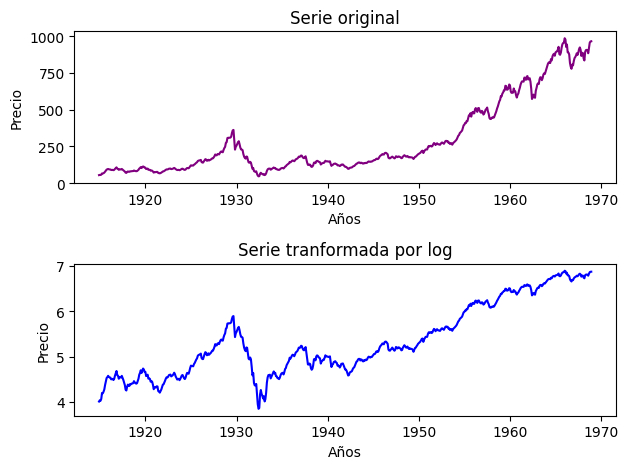

In [99]:
fig, ax = plt.subplots(nrows= 2, ncols= 1)
ax[0].plot(stock.Date, stock.Price, color = 'purple')
ax[0].set_xlabel('Años')
ax[0].set_ylabel('Precio')
ax[0].set_title('Serie original')

ax[1].plot(stock.Date, np.log(stock.Price), color = 'blue')
ax[1].set_xlabel('Años')
ax[1].set_ylabel('Precio')
ax[1].set_title('Serie tranformada por log')
plt.tight_layout()
plt.show()

In [100]:
# Vamos a graficar el set penguins

penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


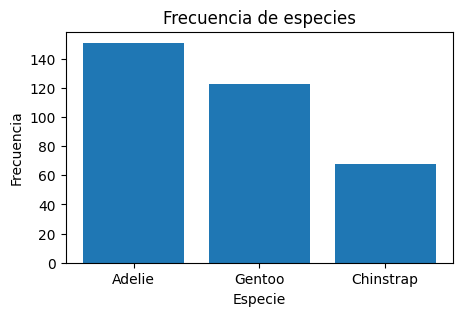

In [110]:
penguins.species.value_counts()

labels = penguins.species.value_counts().index
height = penguins.species.value_counts().values

plt.figure(figsize=(5,3))
plt.bar(labels, height)
plt.title('Frecuencia de especies')
plt.ylabel('Frecuencia')
plt.xlabel('Especie')
plt.show()

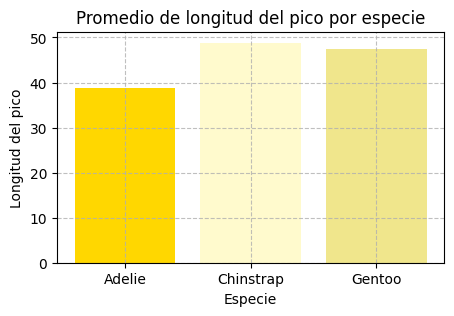

In [120]:
penguins.groupby('species')['bill_length_mm'].mean()

labels = penguins.groupby('species')['bill_length_mm'].mean().index
height = penguins.groupby('species')['bill_length_mm'].mean().values

plt.figure(figsize=(5,3))
plt.bar(labels, height, color = ('gold','lemonchiffon','khaki'))
plt.title('Promedio de longitud del pico por especie')
plt.ylabel('Longitud del pico')
plt.xlabel('Especie')
plt.grid(linestyle = '--', alpha = .8)
plt.show()

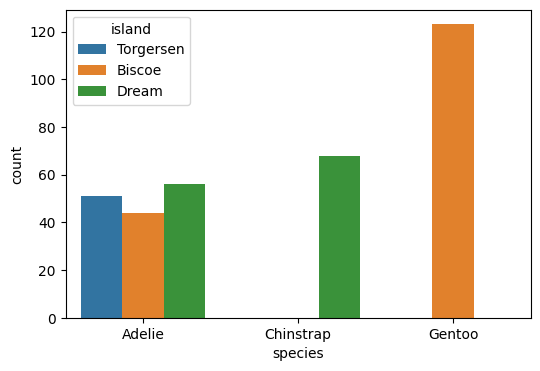

In [124]:
plt.figure(figsize= (6,4))
sns.countplot(data = penguins, x = 'species', hue= 'island')
plt.show()

In [112]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [129]:
penguins.species

labels = penguins.species.value_counts().index
sizes = penguins.species.value_counts().values

labels, sizes

(Index(['Adelie', 'Gentoo', 'Chinstrap'], dtype='object', name='species'),
 array([151, 123,  68]))

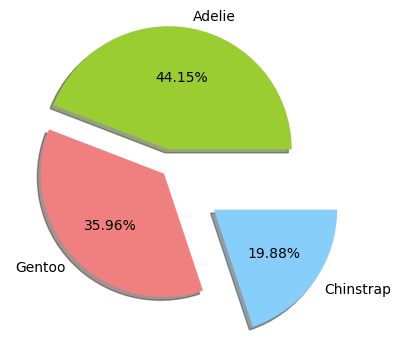

In [142]:
plt.figure(figsize=(4,4))
plt.pie(sizes,labels = labels, autopct= '%1.2f%%', shadow= True, explode= (0.2,0,.5), colors = ['yellowgreen', 'lightcoral', 'lightskyblue'])

plt.show()

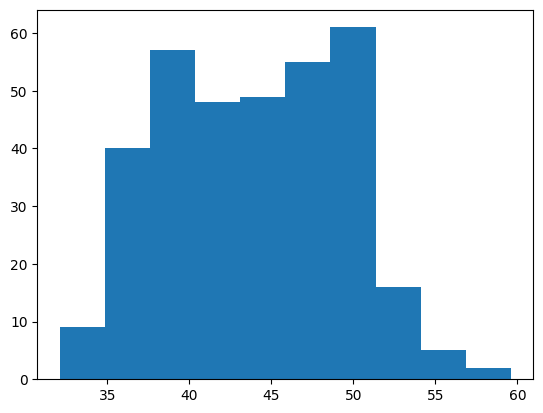

In [148]:
# Con variables cuantitativas

plt.hist(penguins.bill_length_mm, bins= 'sturges')
plt.show()

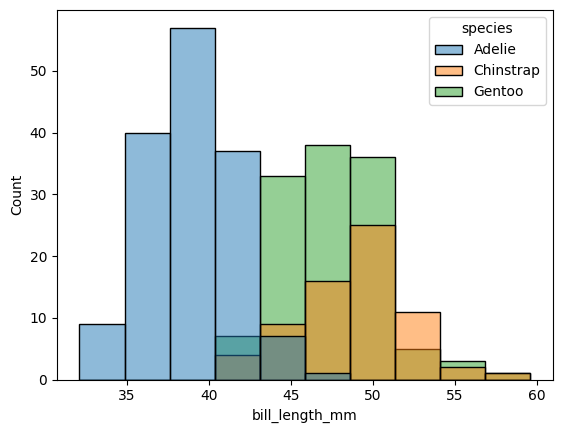

In [156]:
sns.histplot(data = penguins, x = 'bill_length_mm', bins= 'sturges', hue = 'species');

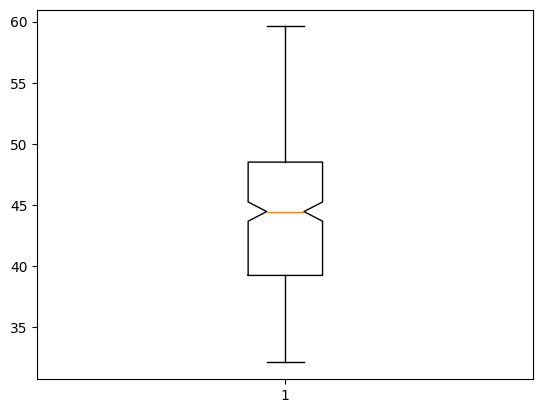

In [153]:
plt.boxplot(penguins.bill_length_mm, notch= True);

<Axes: ylabel='bill_length_mm'>

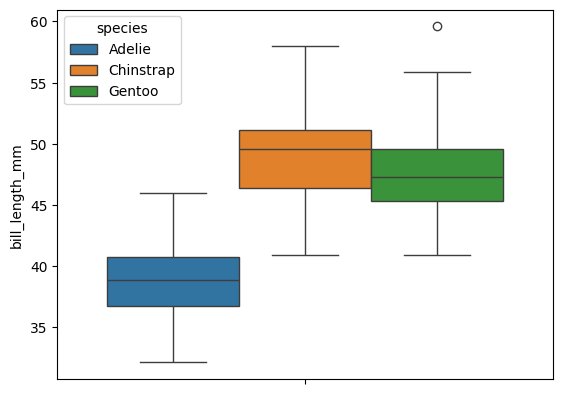

In [155]:
sns.boxplot(data = penguins, y = 'bill_length_mm', hue = 'species')

In [143]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')